<font size="5"><center>Taller de procesamiento de señales

<font size="5">Trabajo práctico N°9

<font size="5">Alumno: Santiago Cabrera

<font size="5">Padrón: 110.445

# a) Procesamiento del catalogo

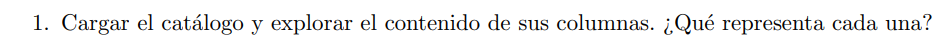

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import requests
import tarfile
import sklearn as sk


In [ ]:
url = "https://web.csc.gob.ar/~jzuloaga/epub/catalog.csv"
catalogo = pd.read_csv(url)
catalogo.head()

catalogo.info()
catalogo.columns
catalogo.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69193 entries, 0 to 69192
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   EPL Id           69193 non-null  int64  
 1   Título           69193 non-null  object 
 2   Autor            69193 non-null  object 
 3   Géneros          69193 non-null  object 
 4   Colección        28801 non-null  object 
 5   Volumen          28920 non-null  float64
 6   Año publicación  69193 non-null  int64  
 7   Sinopsis         69193 non-null  object 
 8   Páginas          69193 non-null  int64  
 9   Revisión         69193 non-null  float64
 10  Idioma           69193 non-null  object 
 11  Publicado        69193 non-null  object 
 12  Estado           69193 non-null  object 
 13  Valoración       67352 non-null  float64
 14  Nº Votos         69193 non-null  int64  
 15  Enlace(s)        69193 non-null  object 
dtypes: float64(3), int64(4), object(9)
memory usage: 8.4+ MB


,EPL Id,Título,Autor,Géneros,Colección,Volumen,Año publicación,Sinopsis,Páginas,Revisión,Idioma,Publicado,Estado,Valoración,Nº Votos,Enlace(s)
40568,51951,Manual de Historia Política y Social de España...,Miguel Martorell & Santos Juliá,Historia,NaN,NaN,2012,Esta obra se trata de un manual de historia co...,426,1.0,Español,P:26-10-2019,Disp.,7.3,6,05C3143BAAD987A707A714C7FCB20595816E6844
35115,55261,Dos amants com nosaltres,Laura Borràs,Crítica y teoría literaria,NaN,NaN,2012,Com han estimat els catalans al llarg dels seg...,153,1.1,Catalán,A:23-07-2020,Ver.,9.4,5,3D59F3F66084C261031A84B9085BA783621C61D4
6222,76551,Cartas,Cipriano de Cartago,Memorias,Biblioteca Clásica Gredos,255.0,258,San Cipriano (muerto en 258 d. C.) fue obispo ...,409,1.0,Español,P:15-08-2024,Disp.,10.0,6,E57B1A356A7B8B249B3563C9B9DED2C27D069C9D
56948,32010,The Fireman,Joe Hill,"Fantástico, Terror",NaN,NaN,2016,"From the award-winning, New York Times bestsel...",592,1.0,Inglés,P:26-09-2016,Disp.,8.7,3,D1324FE12CCDADBAB398A351E42C8F4655FE7B99
56129,33808,Los imperios del Antiguo Oriente III,Elena Cassin & Jean Vercoutter & Jean Bottéro,Historia,Historia Universal Siglo XXI,4.0,1965,"Esta Historia universal SIGLO XXI, preparada y...",340,1.0,Español,P:24-11-2016,Ver.,9.9,16,39557F991C494B7768FA73FD40D7A86E3EB8AC97


El catálogo tiene 69193 entradas, cada una con 16 columnas

Entre las columnas tenemos un Id, Título, autor, género, año de publicación y otros

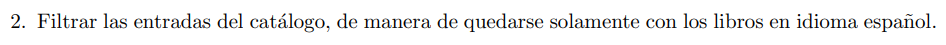

In [ ]:
catalogo_filtrado = catalogo[catalogo['Idioma'] == 'Español']
print(f'Ahora el catálogo tiene {len(catalogo_filtrado)} entradas')

Ahora el catálogo tiene 61063 entradas


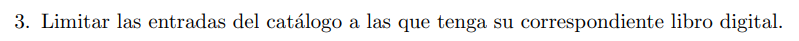

Importo los libros

In [ ]:
compressed_url = 'https://web.csc.gob.ar/~jzuloaga/epub/compressed.tar'
compressed_file = 'compressed.tar'

#Paso 1: descargar el .tar
if not os.path.exists(compressed_file):
    print(f"Descargando {compressed_file}...")
    r = requests.get(compressed_url, stream=True) #crea un request GET de HTTP
    with open(compressed_file, 'wb') as f: #abre el archivo para escribir
        for chunk in r.iter_content(chunk_size = 8192): #escribe chunk a chunk
            f.write(chunk)
    print("Descarga completada.")
else:
    print(f"{compressed_file} ya existe localmente.")


#paso 2: Extraer los archivos del .tar
output_dir = "libros"
os.makedirs(output_dir, exist_ok=True)

print(f"Extrayendo {compressed_file}...")
with tarfile.open(compressed_file, 'r') as tar:
    tar.extractall(path = output_dir, filter = "data")
print("Extracción completada.")

Descargando compressed.tar...
Descarga completada.
Extrayendo compressed.tar...
Extracción completada.


In [ ]:
dir_libros = 'libros/compressed'
entradas = os.listdir(dir_libros) #da una lista de las entradas en libros/compressed

print(f'En el directorio hay {len(entradas)} archivos')

En el directorio hay 8958 archivos


In [ ]:
ids_en_directorio = [os.path.splitext(f)[0] for f in entradas] #splitext separa el nombre del archivo y la extensión. [0] me da el nombre, que es un string
ids_en_directorio = [int(id) for id in ids_en_directorio] #paso del string al valor numérico


catalogo_final = catalogo_filtrado[catalogo_filtrado['EPL Id'].isin(ids_en_directorio)].copy() #nota: .copy() crea un df independiente

print(f'Después de filtrar, el catálogo tiene {len(catalogo_final)} entradas.')

Después de filtrar, el catálogo tiene 8958 entradas.


#b) Definición de las clases


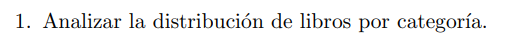

In [ ]:
#separo los géneros
generos_separados = catalogo_final['Géneros'].str.split(', ')
#(8958 x 1) a cada libro le corresponde una lista con sus géneros

lista_plana_generos = [item for sublist in generos_separados for item in sublist] #aplano todas las entradas de generos_separados

"""Equivale a:
lista_plana_generos = []
for sublist in generos_separados:
    for item in sublist:
        lista_plana_generos.append(item)

"""
lista_generos = sorted(list(set(lista_plana_generos))) #set() crea un conjunto. Cada genero aparece una sola vez. Lo hago lista y lo ordeno alfabéticamente
#esta lista contiene todos los géneros que hay

In [ ]:
#Codifico la serie generos_separados en una matriz one-hot-encoding (OHE)

datos_matriz_generos = {} #diccionario vacío

#itero sobre todos los libros
for i, lista_generos_del_libro in generos_separados.items():
    fila_generos = [1 if genero in lista_generos_del_libro else 0 for genero in lista_generos]

    datos_matriz_generos[i] = fila_generos

df_generos = pd.DataFrame.from_dict(datos_matriz_generos, orient = 'index', columns = lista_generos)

df_generos.columns = [f'{genero}' for genero in lista_generos] #añado nombres a las columnas

print(f'La matriz OHE tiene dimensiones {df_generos.shape}')
print(f'Cada una de las {df_generos.shape[0]} filas representa un libro.\n Cada una de las {df_generos.shape[1]} columnas representa un género.')

La matriz OHE tiene dimensiones (8958, 61)
Cada una de las 8958 filas representa un libro.
 Cada una de las 61 columnas representa un género.


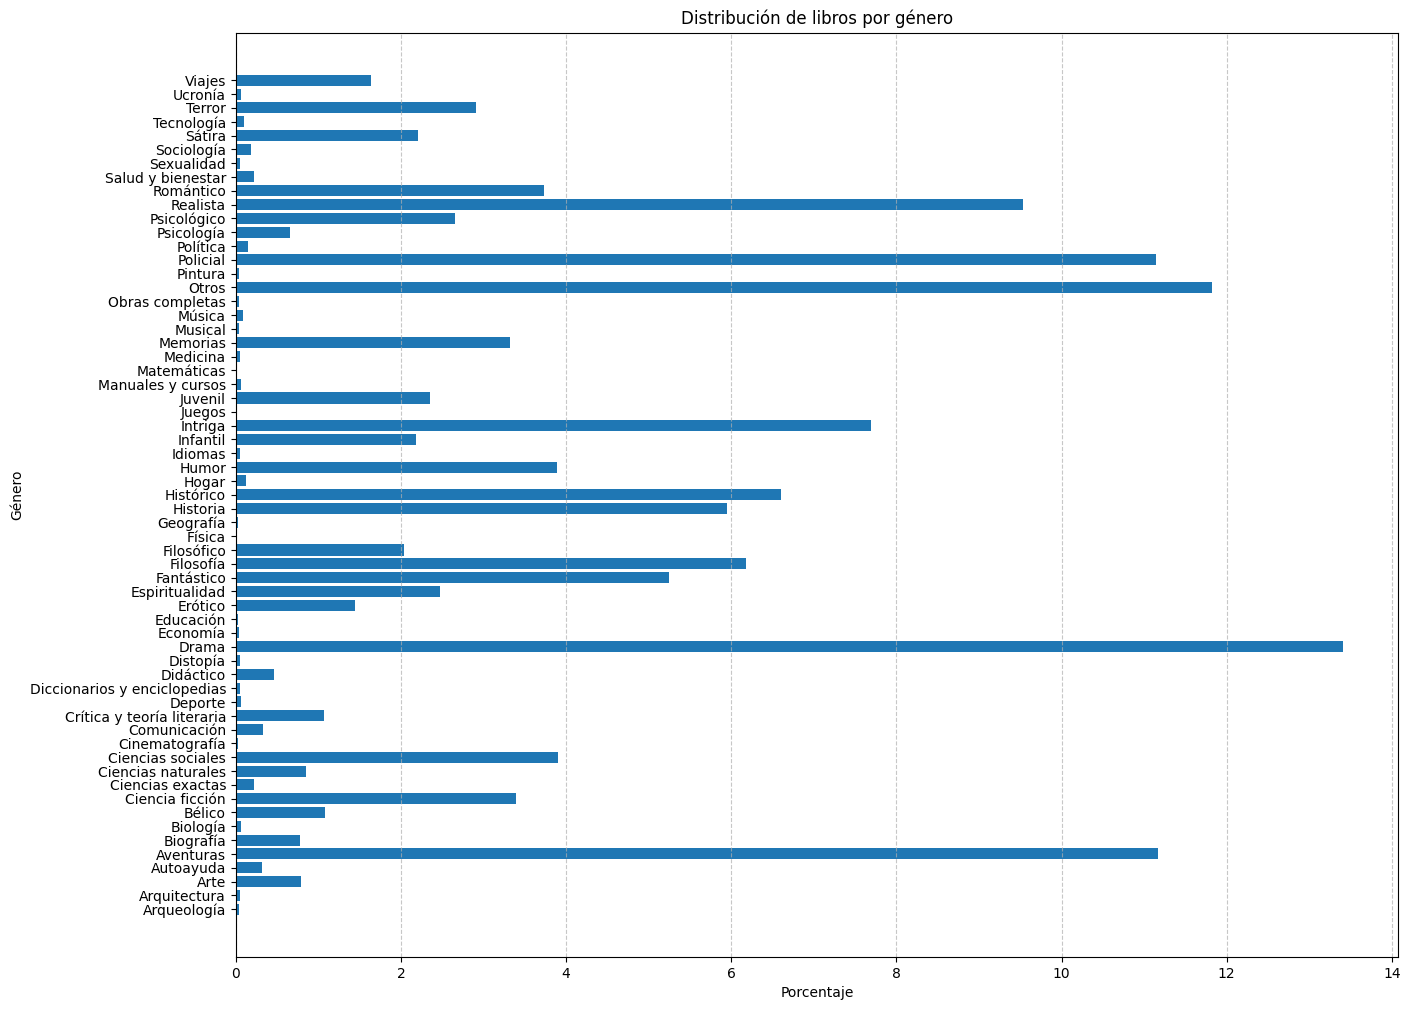

In [ ]:
libros_por_genero = np.sum(df_generos, axis = 0)
plt.figure(figsize = (15, 12))

n_libros = len(generos_separados)
plt.barh(lista_generos, libros_por_genero * 100 / n_libros)

plt.ylabel('Género')
plt.xlabel('Porcentaje')
plt.title('Distribución de libros por género')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

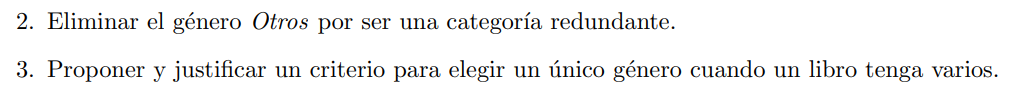

Antes de proponer un criterio para reducir el número de géneros por libro a 1, se hará un análisis de la distribución de los géneros

¿Cuántos géneros hay?

In [ ]:
n_generos = len(lista_generos)
print(f'Hay {n_generos} géneros.')

Hay 61 géneros.


¿Cuál es el género más frecuente? ¿Cuál es el menos frecuente?

In [ ]:
idx_max = np.argmax(libros_por_genero)
idx_min = np.argmin(libros_por_genero)

print(f'El género más frecuente es {lista_generos[idx_max]}. De los {len(generos_separados)} libros, {libros_por_genero.iloc[idx_max]} tienen ese género.')
print(f'El género menos frecuente es {lista_generos[idx_min]}. De los {len(generos_separados)} libros, {libros_por_genero.iloc[idx_min]} tienen ese género')

El género más frecuente es Drama. De los 8958 libros, 1201 tienen ese género.
El género menos frecuente es Física. De los 8958 libros, 1 tienen ese género


¿Cuál es el libro que más géneros tiene? ¿Cuántos tiene?

In [ ]:
generos_por_libro = np.sum(df_generos, axis = 1)
cantidad_de_generos = np.max(generos_por_libro)
idx = np.argmax(np.sum(df_generos, axis = 1))
print(f'El libro que más géneros tiene es "{catalogo_final.iloc[idx]['Título']}"\n Tiene {cantidad_de_generos} géneros, que son {catalogo_final.iloc[idx]['Géneros']}')

El libro que más géneros tiene es "Cuentos de cabecera"
 Tiene 6 géneros, que son Aventuras, Fantástico, Humor, Infantil, Juvenil, Sátira


¿Cómo es la distribución del número de géneros por libro?

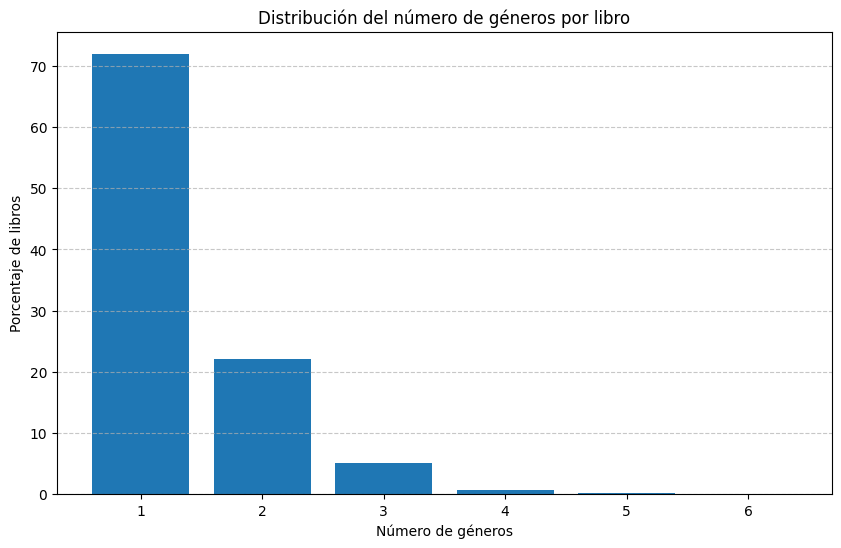

Se observa que el 94.05% de los libros tienen 2 géneros o menos
El 5.95% de los libros tienen más de 2 géneros


In [ ]:
#Calcular la frecuencia de cada número de géneros
conteo_generos = generos_por_libro.value_counts() #cuenta las veces que se repiten los números en la serie generos_por_libro

porcentaje_generos = conteo_generos / n_libros * 100

plt.figure(figsize=(10, 6))
plt.bar(porcentaje_generos.index, porcentaje_generos.values)
plt.xlabel('Número de géneros')
plt.ylabel('Porcentaje de libros')
plt.title('Distribución del número de géneros por libro')
plt.xticks(porcentaje_generos.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f'Se observa que el {porcentaje_generos.iloc[0] + porcentaje_generos.iloc[1]:.2f}% de los libros tienen 2 géneros o menos')
libros_con_mas_de_2_generos = porcentaje_generos.iloc[2] + porcentaje_generos.iloc[3] + porcentaje_generos.iloc[4] + porcentaje_generos.iloc[5]
print(f'El {libros_con_mas_de_2_generos:.2f}% de los libros tienen más de 2 géneros')

## Criterio:
Se observa que la gran mayoría de los libros tiene un solo género, por lo que cualquiera sea el criterio que se elija, la mayoría de los libros no se verá afectada.

Por otro lado, se observa que hay géneros con muy pocos libros, como 'Física' o 'Pintura'. Estos géneros son outliers que entorpecerán el rendimiento del algoritmo, por lo que es preferible descartarlos.

Por esto, el criterio a utilizar será el siguiente:

1) Si el libro tiene un solo género, se elegirá ese género, a menos que el mismo sea 'Otros', en cuyo caso se eliminará el libro de la base de datos.

2) Cuando haya más de un género se elegirá el género más frecuente, excepto cuando el mismo sea el género 'Otros', en cuyo caso se elegirá el segundo género más frecuente.

Este criterio tiende a hacer la base de datos más homogenea. Sin embargo, como los géneros menos frecuentes se descartarán el número de géneros final será menor que el original.

In [ ]:
catalogo_final = catalogo_filtrado[catalogo_filtrado['EPL Id'].isin(ids_en_directorio)].copy()
#redefino el catalogo_final cada vez que se ejecute la celda
etiquetas = []
lista_indices_a_eliminar = []
for indx, lista_de_generos in generos_separados.items():
  if len(lista_de_generos) == 1:

    if lista_de_generos[0] == 'Otros':
      lista_indices_a_eliminar.append(indx)
      continue

    etiquetas.append(lista_de_generos[0])
    continue

  else:
    frecuencias = libros_por_genero[lista_de_generos]
    indx = np.argmax(frecuencias)
    genero_mas_frecuente = lista_de_generos[indx]

    if genero_mas_frecuente == 'Otros':
      lista_de_generos.remove('Otros')

      frecuencias = libros_por_genero[lista_de_generos]
      indx = np.argmax(frecuencias)
      genero_mas_frecuente = lista_de_generos[indx]
      etiquetas.append(genero_mas_frecuente)
    else:
      etiquetas.append(genero_mas_frecuente)


catalogo_final.drop(lista_indices_a_eliminar, inplace = True)
etiquetas = pd.Series(etiquetas, index = catalogo_final.index)
catalogo_final['Géneros'] = etiquetas #reescribo el catálogo

In [ ]:
generos_en_etiquetas = etiquetas.unique()
generos_en_etiquetas = pd.Series(np.sort(generos_en_etiquetas))
num_generos_en_etiquetas = len(generos_en_etiquetas)

print(f'Hay {num_generos_en_etiquetas} géneros únicos en la serie "etiquetas".')

generos_solo_en_lista_generos = set(lista_generos) - set(generos_en_etiquetas)
num_generos_solo_en_lista_generos = len(generos_solo_en_lista_generos)

print(f'Hay {num_generos_solo_en_lista_generos} géneros que aparecen en "lista_generos" pero no en "etiquetas".')
print(f'Estos géneros son: {generos_solo_en_lista_generos}')

n_libros = len(catalogo_final)
n_generos = len(generos_en_etiquetas)
print(f'Finalmente, el catalogo final tiene {n_libros} libros  y {num_generos_en_etiquetas} géneros')

Hay 54 géneros únicos en la serie "etiquetas".
Hay 7 géneros que aparecen en "lista_generos" pero no en "etiquetas".
Estos géneros son: {'Otros', 'Física', 'Sexualidad', 'Economía', 'Pintura', 'Arqueología', 'Cinematografía'}
Finalmente, el catalogo final tiene 8163 libros  y 54 géneros


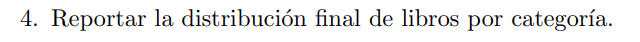

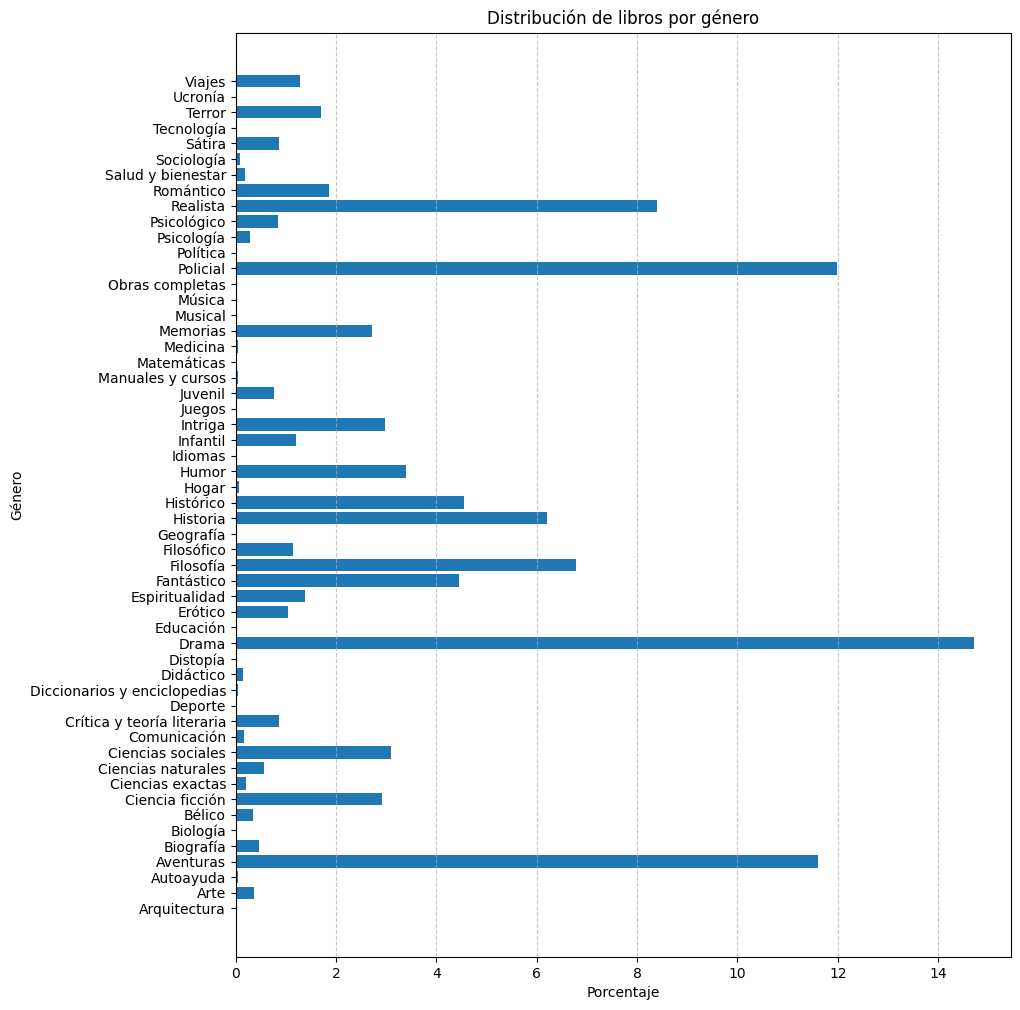

In [ ]:
libros_por_categoria = etiquetas.value_counts().sort_index()

plt.figure(figsize=(10, 12))
plt.barh(generos_en_etiquetas, libros_por_categoria / len(etiquetas) * 100)

plt.ylabel('Género')
plt.xlabel('Porcentaje')
plt.title('Distribución de libros por género')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
for genero in generos_en_etiquetas:
  print(f'El {libros_por_categoria[genero]/ n_libros * 100 :.2f}% son del género {genero}')

El 0.01% son del género Arquitectura
El 0.37% son del género Arte
El 0.05% son del género Autoayuda
El 11.60% son del género Aventuras
El 0.45% son del género Biografía
El 0.01% son del género Biología
El 0.34% son del género Bélico
El 2.92% son del género Ciencia ficción
El 0.21% son del género Ciencias exactas
El 0.56% son del género Ciencias naturales
El 3.10% son del género Ciencias sociales
El 0.16% son del género Comunicación
El 0.87% son del género Crítica y teoría literaria
El 0.02% son del género Deporte
El 0.05% son del género Diccionarios y enciclopedias
El 0.15% son del género Didáctico
El 0.01% son del género Distopía
El 14.71% son del género Drama
El 0.02% son del género Educación
El 1.04% son del género Erótico
El 1.37% son del género Espiritualidad
El 4.46% son del género Fantástico
El 6.77% son del género Filosofía
El 1.14% son del género Filosófico
El 0.01% son del género Geografía
El 6.20% son del género Historia
El 4.54% son del género Histórico
El 0.07% son del gén

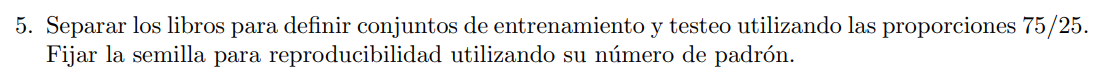

In [ ]:
ids = catalogo_final['EPL Id']
y = etiquetas

ids_train, ids_test, y_train, y_test = sk.model_selection.train_test_split(ids, y, test_size = 0.25, random_state = 110445)

print("Shape de ids_train:", ids_train.shape)
print("Shape de ids_test:", ids_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de ids_train: (6122,)
Shape de ids_test: (2041,)
Shape de y_train: (6122,)
Shape de y_test: (2041,)


#c) Procesamiento de texto

In [ ]:
#en esta celda reduzco el tamaño del dataset si es necesario
"""
N_train = int(len(ids_train)/100)
N_test = int(0.25 * N_train)

ids_train = ids_train.iloc[0:N_train]
y_train = y_train.iloc[0:N_train]

ids_test = ids_test.iloc[0:N_test]
y_test = y_test.iloc[0:N_test]

print("Shape de ids_train:", ids_train.shape)
print("Shape de ids_test:", ids_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)
"""

'\nN_train = int(len(ids_train)/50)\nN_test = int(0.25 * N_train)\n\nids_train = ids_train.iloc[0:N_train]\ny_train = y_train.iloc[0:N_train]\n\nids_test = ids_test.iloc[0:N_test]\ny_test = y_test.iloc[0:N_test]\n\nprint("Shape de ids_train:", ids_train.shape)\nprint("Shape de ids_test:", ids_test.shape)\nprint("Shape de y_train:", y_train.shape)\nprint("Shape de y_test:", y_test.shape)\n'

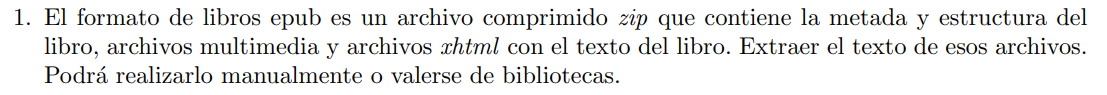

In [ ]:
!pip install ebooklib beautifulsoup4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.3 MB/s eta 0:00:00


In [ ]:
import ebooklib
from ebooklib import epub
from bs4 import BeautifulSoup

def extraer_texto_epub(path):
    textos = []
    try: #intenta ejecutar este codigo. Si hay error, pasa directamente al except
        libro = epub.read_epub(path)
        for item in libro.get_items():

            if item.get_type() == ebooklib.ITEM_DOCUMENT:
                soup = BeautifulSoup(item.get_content(), 'html.parser')
                contenido = soup.get_text(separator=' ', strip=True)
                textos.append(contenido)

    except Exception as e:
        print(f"Error al leer el archivo {path}: {e}")
        return ""


    return "\n".join(textos)


def generador_epubs(lista_ids, ruta_carpeta = 'libros/compressed'):
    for book_id in lista_ids:
        filepath = os.path.join(ruta_carpeta, f"{book_id}.epub")
        if os.path.exists(filepath):
            texto = extraer_texto_epub(filepath)
            if texto != "":
              yield texto
        else:
            print(f"No se encontró el archivo para el ID {book_id} en {filepath}")

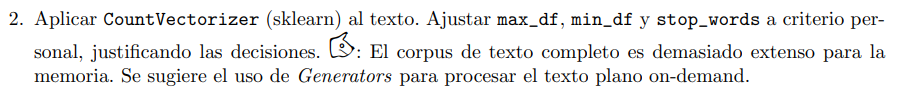

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    input = "content",
    decode_error = 'ignore',
    lowercase=True,
    max_df = 0.7,
    min_df = 0.3
)


gen_train = generador_epubs(ids_train)
X_train = vectorizer.fit_transform(gen_train)

gen_test = generador_epubs(ids_test)
X_test = vectorizer.transform(gen_test)


Error al leer el archivo libros/compressed/38432.epub: "There is no item named 'OEBPS/Fonts/bakery.ttf' in the archive"
Error al leer el archivo libros/compressed/42080.epub: "There is no item named 'META-INF/container.xml' in the archive"
Error al leer el archivo libros/compressed/45806.epub: "There is no item named 'OEBPS/Text/Acto01.xhtml' in the archive"
Error al leer el archivo libros/compressed/64292.epub: "There is no item named 'OEBPS/Text/autor.xhtml' in the archive"
Error al leer el archivo libros/compressed/7517.epub: "There is no item named 'OEBPS/Text/Chapter1.xhtml' in the archive"
Error al leer el archivo libros/compressed/19881.epub: "There is no item named 'OEBPS/toc.ncx' in the archive"
Error al leer el archivo libros/compressed/26704.epub: "There is no item named 'META-INF/container.xml' in the archive"
Error al leer el archivo libros/compressed/13872.epub: "There is no item named 'OEBPS/toc.ncx' in the archive"
Error al leer el archivo libros/compressed/54762.epub: 

df significa document frequency

max_df: las palabras que tengan una df mayor a max_df serán eliminadas del vocabulario

min_df: las palabras que tengan una df menor que min_df serán eleminadas.

max_df sirve para eliminar palabras que aparezcan muchas veces en todos los documentos, tales como los artículos

min_df serive para eliminar palabras que solo aparecen en documentos específicos

De esta manera, se reduce el tamaño del vocabulario, lo que reduce el tiempo de cómputo. Además, al eliminar palabras específicas de cada docuemnto se reduce el overfiting.

También cabe mencionar que si min_df es demasiado grande, la performance del algoritmo empeorará para los géneros menos comunes, ya que el algoritmo podría no ver ninguna palabra de los docuemtos de ese genero

In [ ]:
print(f'En los {X_train.shape[0]} libros vistos en el entrenamiento se observaron {X_train.shape[1]} palabras')

En los 6092 libros vistos en el entrenamiento se observaron 6218 palabras


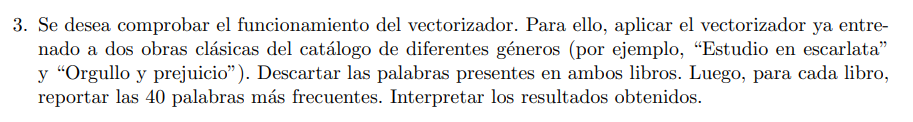

In [ ]:
id_ES = catalogo_final[catalogo_final['Título'] == "Estudio en escarlata"]['EPL Id'].iloc[0]
id_OyP = catalogo_final[catalogo_final['Título'] == "Orgullo y prejuicio"]['EPL Id'].iloc[0]

gen = generador_epubs( [id_ES, id_OyP] )

X = vectorizer.transform(gen).toarray()

In [ ]:
palabras_en_comun = (X[0, :] != 0) & (X[1, :] != 0)

contador_palabras_ES = X[0, :]
contador_palabras_ES[palabras_en_comun] = 0

contador_palabras_OyP = X[1, :]
contador_palabras_OyP[palabras_en_comun] = 0

vocabulario = np.array(vectorizer.get_feature_names_out())


top_40_indices_ES = np.argsort(contador_palabras_ES)[::-1][:40] #me quedo con los indices de las 40 palabras más frecuentes
top_40_palabras_ES = vocabulario[top_40_indices_ES] #me quedo con las 40 palabras más frecuentes
top_40_veces_ES = contador_palabras_ES[top_40_indices_ES] #me quedo con cuántas veces aparecieron esas palabras

top_40_indices_OyP = np.argsort(contador_palabras_OyP)[::-1][:40]
top_40_palabras_OyP = vocabulario[top_40_indices_OyP]
top_40_veces_OyP = contador_palabras_OyP[top_40_indices_OyP]

print("Top 40 palabras más frecuentes en 'Estudio en escarlata' (excluyendo palabras comunes):")
for palabra, veces in zip(top_40_palabras_ES, top_40_veces_ES):
    print(f"{palabra}: {veces}")

print("\nTop 40 palabras más frecuentes en 'Orgullo y prejuicio' (excluyendo palabras comunes):")
for palabra, veces in zip(top_40_palabras_OyP, top_40_veces_OyP):
    print(f"{palabra}: {veces}")

Top 40 palabras más frecuentes en 'Estudio en escarlata' (excluyendo palabras comunes):
mas: 39
policía: 16
crimen: 16
asesino: 15
asesinato: 15
secretario: 13
anuncio: 11
prisionero: 11
botas: 11
carretera: 11
anciano: 10
criminal: 10
periódico: 9
datos: 9
investigación: 9
medicina: 9
gris: 9
señales: 9
veneno: 9
faz: 8
examen: 8
eché: 8
desierto: 8
horizonte: 7
cadáver: 7
manchas: 7
vela: 7
constituye: 7
señalaba: 7
muestras: 7
ancianos: 7
súbito: 7
pese: 6
trance: 6
vistazo: 6
plazo: 6
estrépito: 6
flor: 6
sucesión: 6
demonios: 6

Top 40 palabras más frecuentes en 'Orgullo y prejuicio' (excluyendo palabras comunes):
hijas: 88
hermanas: 86
coronel: 72
tía: 64
capítulo: 62
baile: 58
tío: 50
william: 42
cortesía: 41
atenciones: 35
señoras: 34
casarse: 34
modales: 33
muchachas: 30
educación: 25
sobrino: 25
primo: 24
bailar: 24
prima: 24
biblioteca: 23
maría: 23
convencida: 23
contestar: 21
velada: 20
aseguro: 20
tuviese: 20
enamorado: 18
orgulloso: 18
amabilidad: 18
indiferencia: 18
est

Se observa que las palabras más comunes de cada libro pueden asociarse al género de los mismos. Además, no aparecen palabras específicas de cada libro (como podrían ser los nombres de los personajes)

#d) MNB

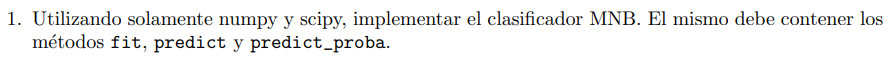

In [ ]:
class MNB:
  def __init__(self, alfa = 1):
    self.alfa = alfa
    self.bolsa = None
    self.priors = None
    self.n_clases = None
    self.lista_clases = None
    self.V = None
    self.n_docs = None #numero de documentos
    self.Titas = None
    self.N = None #lo que en la teórica es Ñ_m^(k)
    return

  def fit(self, X, y):
    self.bolsa = X.toarray() #en realidad la bolsa debería sacarla con countvectorizer DENTRO de esta clase. El usuario no me daría la bolsa ya hecha
    self.lista_clases = np.sort(y.unique())

    self.priors = y.value_counts(normalize=True).reindex(index = self.lista_clases, fill_value = 0).to_numpy()
    #los priors deben estar alineados con self.lista_clases.

    self.n_clases = len(self.lista_clases)
    self.n_docs, self.V = self.bolsa.shape #numero de documentos y largo del vocabulario
    self.Titas = np.zeros((self.n_clases, self.V)) #filas->clases, columnas->palabras

    self.N = np.zeros((self.n_clases, self.V))

    for i in range(self.n_docs):
      clase = y.iloc[i]
      indx = np.where(self.lista_clases == clase)[0][0]
      self.N[indx] += self.bolsa[i, :]

    self.Titas = (self.N + self.alfa) / (self.N.sum(axis = 1).reshape(-1, 1) + self.alfa * self.V)
    #(n_clases, V)
    return

  def predict(self, X):
    log_proba = self.predict_log_proba(X)
    return self.lista_clases[np.argmax(log_proba, axis = 1)]


  def predict_log_proba(self,X):

    log_suma = X @ np.log(self.Titas.T)
    #(n_doc_a_predict, V) x (V, n_clases) = (n_docs_a_predict, clases)

    log_prior = np.log(self.priors)
    log_proba = log_suma + log_prior #(n_docs_a_predict, n_clases)

    return log_proba


  def predict_proba(self, X):
    log_proba = self.predict_log_proba(X)
    exp = np.exp(log_proba)
    return exp / exp.sum(axis = 1).reshape(-1, 1)

  def accuracy(self, X, y):
    y_pred = self.predict(X)
    return np.mean(y_pred == y)

  def macro_F1(self, X, y):
    y_pred = self.predict(X)
    f1_scores = [] #tengo una f1 por clase

    for clase in self.lista_clases:
        tp = np.sum((y == clase) & (y_pred == clase))
        fp = np.sum((y != clase) & (y_pred == clase))
        fn = np.sum((y == clase) & (y_pred != clase))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0


        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores.append(f1)

    macro_f1 = np.mean(f1_scores) #la f1 final es el promedio de las f1 sobre las clases
    return macro_f1

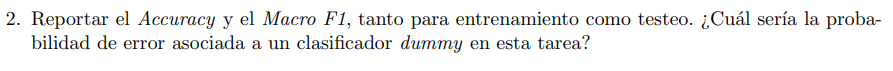

In [ ]:
mi_clase = MNB() # ¿qué pasa para otros valores de alfa?

In [ ]:
mi_clase.fit(X_train, y_train)

In [ ]:
acc_train = mi_clase.accuracy(X_train, y_train)
acc_test = mi_clase.accuracy(X_test, y_test)

f1_train = mi_clase.macro_F1(X_train, y_train)
f1_test = mi_clase.macro_F1(X_test, y_test)

print('Accuracy train: ', acc_train)
print('Accuracy test: ', acc_test)
print('F1 train: ', f1_train)
print('F1 test: ', f1_test)

ValueError: ('Lengths must match to compare', (6122,), (6092,))

In [ ]:
n_clases = mi_clase.n_clases
print(f'El número de clases es {n_clases}\nPara un clasificador dummy, la probabilidad de error es {1 - 1/n_clases:.2f}')
print(f'Por lo tanto, si bien el accuracy de testeo no es muy elevado, este predictor es mejor que el dummy')

El número de clases es 25
Para un clasificador dummy, la probabilidad de error es 0.96
Por lo tanto, si bien el accuracy de testeo no es muy elevado, este predictor es mejor que el dummy


Con el 1% del conjunto de entrenamiento (65 libros) obtuve los siguientes resultados:

Accuracy train: 0.800

Accuracy test: 0.438

F1 train:      0.595

F1 test:        0.102


Con el 100% del conjunto de entrenamiento (6122 libros) obtuve:

Accuracy train: 0.538

Accuracy test: 0.489

F1 train: 0.611

F1 test: 0.309

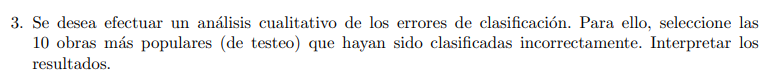

In [ ]:
clases_verdaderas = etiquetas.loc[ids_test.index] #ids_test.indx todavía tienen los indices de catalogo_final, que comparte con la serie etiquetas
clases_predict = pd.Series(mi_clase.predict(X_test), index = clases_verdaderas.index)
#es más cómodo crear una serie con los indices alineados

mal_clasificados_mascara = clases_predict != clases_verdaderas
mal_clasificados_ids = ids_test[mal_clasificados_mascara]
catalogo_mal_clasificados = catalogo_final.loc[mal_clasificados_ids.index]

print(f'Después de alinear las predicciones, hay {len(mal_clasificados_ids)} libros mal clasificados.')

Después de alinear las predicciones, hay 14 libros mal clasificados.


In [ ]:
top_10_mal_clasificados = catalogo_mal_clasificados.sort_values(by = 'Valoración', ascending = False).head(10)

print("Los 10 libros mal clasificados con mejor valoración:")
display(top_10_mal_clasificados)

Los 10 libros mal clasificados con mejor valoración:


,EPL Id,Título,Autor,Géneros,Colección,Volumen,Año publicación,Sinopsis,Páginas,Revisión,Idioma,Publicado,Estado,Valoración,Nº Votos,Enlace(s)
2482,78956,Vieja Navidad,Washington Irving,Humor,NaN,NaN,1876,"Washington Irving nos dejó una obra memorable,...",74,1.0,Español,P:16-03-2025,Disp.,10.0,5,3CA472EA5E697C257FE9A16DAAB267BA97C5FDE6
25027,64126,Delora el enigmático,E. Phillips Oppenheim,Intriga,Obras completas de Oppenheim - Editorial Cerva...,67.0,1910,El capitán Austen Rotherby tiene una misión en...,192,1.0,Español,P:01-12-2021,Disp.,10.0,4,14D2DED0B123A7AC6C06DC9CC26500E807026027
3264,65332,Vidas paralelas I,Mestrio Plutarco,Biografía,Biblioteca Clásica Gredos,77.0,100,Plutarco (Queronea 50-125 d. C.) ha legado a l...,360,1.7,Español,A:29-01-2025,Disp.,10.0,12,932E573AAABB3AEC9528C43D53183F38FDF82D0B
21871,56909,Las manos,Hong Xiao,Realista,NaN,NaN,1936,Breve cuento escrito en 1936 por Xiao Hong. Au...,19,1.2,Español,A:18-05-2022,Ver.,9.8,5,C41AE322F3C35EEA353E4B22E772BA2AE1A7A8F0
58866,30253,Diez años de destierro,Madame de Staël,Memorias,Penguin Clásicos,0.0,1813,"«Las desgracias sufridas, por mucha amargura q...",330,1.4,Español,A:08-05-2016,Disp.,9.7,7,893330A5C995957E77C9BFCE2D0EC8EAA3C7541C
53649,22745,Historia - Libros III-IV,Heródoto de Halicarnaso,Historia,Biblioteca Clásica Gredos,21.0,-484,Heródoto constituye el último eslabón de una l...,449,1.2,Español,A:02-07-2017,Disp.,9.5,28,504BB90F774F5A72424C2FAB2EC9A70146F6C399
59538,29432,La víctima,Saul Bellow,Realista,NaN,NaN,1947,Con su esposa fuera de casa visitando a su mad...,259,1.0,Español,P:21-03-2016,Disp.,9.5,6,CACG7NZF4RH73QM5GUTUP7T47OE5XR5K
41749,50147,La roca de los muertos & El enemigo del Coyote,José Mallorquí,Aventuras,El Coyote (edición doble),45.0,1946,La roca de los muertos:Un forastero llega a Lo...,162,1.1,Español,A:16-08-2019,Ver.,9.5,6,2HTCNEVJUXJJGCV5ZQQ7SC5IIG3OTVS2
7254,15826,Las alegres comadres de Windsor,William Shakespeare,Humor,NaN,NaN,1599,Falstaff llega a Windsor escaso de fondos. Par...,90,1.2,Español,A:13-06-2024,Ver.,9.3,19,NHIRVQBMPHPGEWAELAC2RKDPE4S626LP
16398,15326,Cuentos fatales,Leopoldo Lugones,Drama,NaN,NaN,1926,Cuentos fatales recoge cinco piezas compuestas...,83,1.3,Español,A:24-02-2023,Ver.,8.8,11,7095899032290064762D02C1F8E6B0F3A6FA4CE3


In [ ]:
mal_clasificados_ids_top10 = top_10_mal_clasificados.index
predichos_top10 = clases_predict.loc[mal_clasificados_ids_top10]
verdaderos_top10 = clases_verdaderas.loc[mal_clasificados_ids_top10]

print("Predicciones y clases verdaderas para los 10 libros mal clasificados:")
for i in range(len(mal_clasificados_ids_top10)):
    print(f"Predicción: {predichos_top10.iloc[i]} || Verdadera: {verdaderos_top10.iloc[i]}")


Predicciones y clases verdaderas para los 10 libros mal clasificados:
Predicción: Terror || Verdadera: Humor
Predicción: Policial || Verdadera: Intriga
Predicción: Filosofía || Verdadera: Biografía
Predicción: Drama || Verdadera: Realista
Predicción: Historia || Verdadera: Memorias
Predicción: Filosofía || Verdadera: Historia
Predicción: Intriga || Verdadera: Realista
Predicción: Drama || Verdadera: Aventuras
Predicción: Drama || Verdadera: Humor
Predicción: Filosófico || Verdadera: Drama


Interpretación: El algoritmo tiene errores en clases que son similares (por ejemplo, Drama/Realista o Historia/Memorias)

Una posible solución para mejorar el desempeño del algoritmo sería reducir el número de clases agrupando clases similares.